In [ ]:
#not that accurate for indian data sets while prediction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


In [ ]:
df = pd.read_csv('Churn_Modelling.csv')

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.describe(include='all')

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [ ]:
column_info = {
    "RowNumber"       : "Serial number — will be DROPPED",
    "CustomerId"      : "Unique ID — will be DROPPED",
    "Surname"         : "Customer surname — will be DROPPED",
    "CreditScore"     : "Credit score (numeric)",
    "Geography"       : "Country: France / Germany / Spain (encode)",
    "Gender"          : "Male / Female (encode)",
    "Age"             : "Customer age (numeric)",
    "Tenure"          : "Years with bank (numeric)",
    "Balance"         : "Account balance (numeric)",
    "NumOfProducts"   : "No. of bank products used (numeric)",
    "HasCrCard"       : "Has credit card? 0/1 (already numeric)",
    "IsActiveMember"  : "Active member? 0/1 (already numeric)",
    "EstimatedSalary" : "Estimated salary (numeric)",
    "Exited"          : "TARGET: 1=churned, 0=stayed"
}

for col, desc in column_info.items():
    print(f"  {col:<22} → {desc}")

  RowNumber              → Serial number — will be DROPPED
  CustomerId             → Unique ID — will be DROPPED
  Surname                → Customer surname — will be DROPPED
  CreditScore            → Credit score (numeric)
  Geography              → Country: France / Germany / Spain (encode)
  Gender                 → Male / Female (encode)
  Age                    → Customer age (numeric)
  Tenure                 → Years with bank (numeric)
  Balance                → Account balance (numeric)
  NumOfProducts          → No. of bank products used (numeric)
  HasCrCard              → Has credit card? 0/1 (already numeric)
  IsActiveMember         → Active member? 0/1 (already numeric)
  EstimatedSalary        → Estimated salary (numeric)
  Exited                 → TARGET: 1=churned, 0=stayed


In [ ]:
#check for the missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct.round(2)
}).sort_values('Missing Count', ascending=False)


In [ ]:
missing_df

,Missing Count,Missing %
RowNumber,0,0.0
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0


In [ ]:
#dropping irrelevant  cols
drop_cols = ['RowNumber', 'CustomerId', 'Surname']
df.drop(columns=drop_cols, inplace=True)

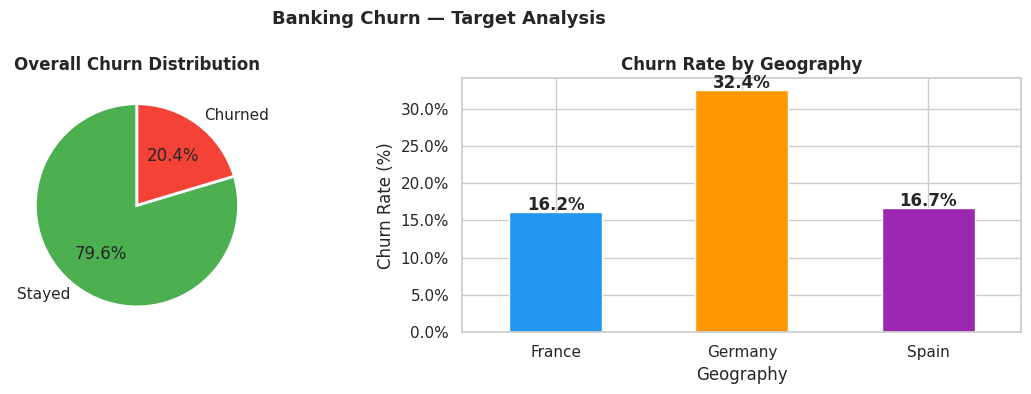

In [ ]:
#exploring target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie
axes[0].pie(
    df['Exited'].value_counts(),
    labels=['Stayed', 'Churned'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Overall Churn Distribution', fontweight='bold')

# Bar by Geography
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
geo_churn.plot(kind='bar', ax=axes[1],
               color=['#2196F3', '#FF9800', '#9C27B0'],
               edgecolor='white', width=0.5)
axes[1].set_title('Churn Rate by Geography', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(geo_churn):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Banking Churn — Target Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('banking_target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

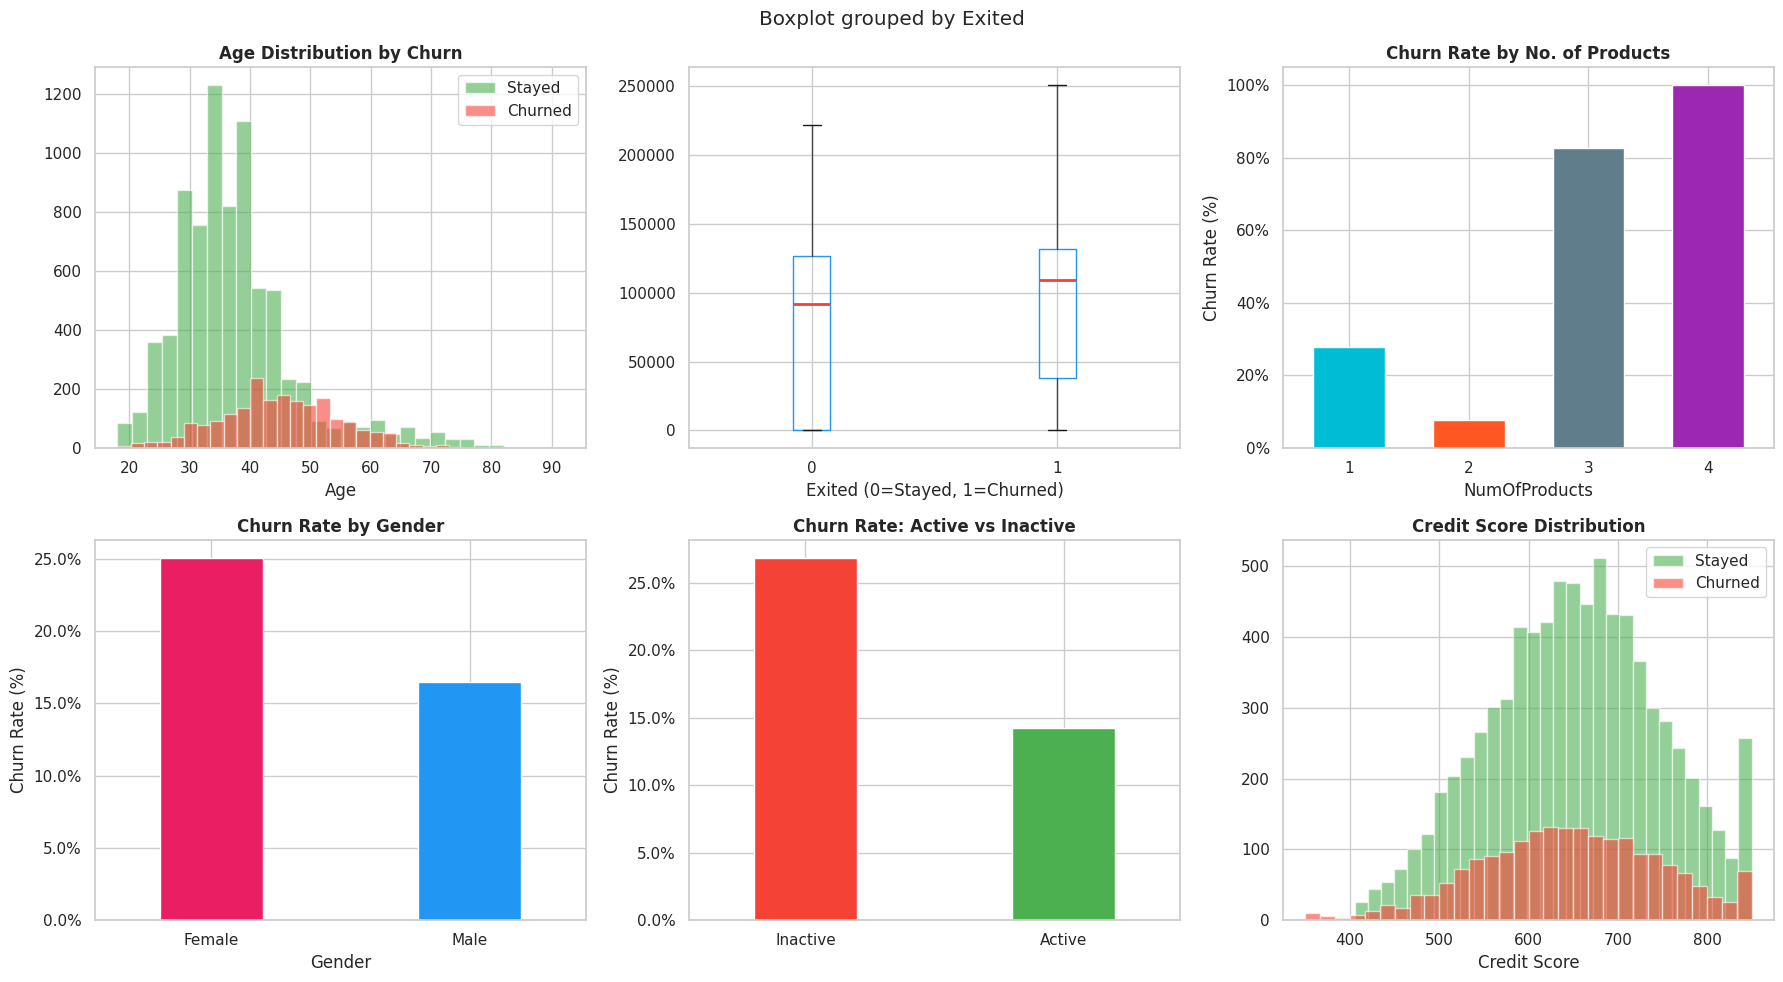

In [ ]:
#eda
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Banking Churn — EDA Overview', fontsize=15, fontweight='bold')

# Plot 1: Age distribution by churn
df[df['Exited']==0]['Age'].hist(ax=axes[0,0], bins=30, alpha=0.6,
                                 color='#4CAF50', label='Stayed')
df[df['Exited']==1]['Age'].hist(ax=axes[0,0], bins=30, alpha=0.6,
                                 color='#F44336', label='Churned')
axes[0,0].set_title('Age Distribution by Churn', fontweight='bold')
axes[0,0].set_xlabel('Age')
axes[0,0].legend()

# Plot 2: Balance by churn
df.boxplot(column='Balance', by='Exited', ax=axes[0,1],
           boxprops=dict(color='#2196F3'),
           medianprops=dict(color='#F44336', linewidth=2))
axes[0,1].set_title('Account Balance by Churn', fontweight='bold')
axes[0,1].set_xlabel('Exited (0=Stayed, 1=Churned)')
plt.sca(axes[0,1]); plt.title('')

# Plot 3: NumOfProducts vs Churn
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
prod_churn.plot(kind='bar', ax=axes[0,2],
                color=['#00BCD4','#FF5722','#607D8B','#9C27B0'],
                edgecolor='white', width=0.6)
axes[0,2].set_title('Churn Rate by No. of Products', fontweight='bold')
axes[0,2].set_ylabel('Churn Rate (%)')
axes[0,2].set_xticklabels(axes[0,2].get_xticklabels(), rotation=0)
axes[0,2].yaxis.set_major_formatter(mtick.PercentFormatter())

# Plot 4: Gender vs Churn
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
gender_churn.plot(kind='bar', ax=axes[1,0],
                  color=['#E91E63', '#2196F3'], edgecolor='white', width=0.4)
axes[1,0].set_title('Churn Rate by Gender', fontweight='bold')
axes[1,0].set_ylabel('Churn Rate (%)')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=0)
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Plot 5: IsActiveMember vs Churn
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
active_churn.index = ['Inactive', 'Active']
active_churn.plot(kind='bar', ax=axes[1,1],
                  color=['#F44336', '#4CAF50'], edgecolor='white', width=0.4)
axes[1,1].set_title('Churn Rate: Active vs Inactive', fontweight='bold')
axes[1,1].set_ylabel('Churn Rate (%)')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter())

# Plot 6: CreditScore distribution
df[df['Exited']==0]['CreditScore'].hist(ax=axes[1,2], bins=30,
                                         alpha=0.6, color='#4CAF50', label='Stayed')
df[df['Exited']==1]['CreditScore'].hist(ax=axes[1,2], bins=30,
                                         alpha=0.6, color='#F44336', label='Churned')
axes[1,2].set_title('Credit Score Distribution', fontweight='bold')
axes[1,2].set_xlabel('Credit Score')
axes[1,2].legend()

plt.tight_layout()
#plt.savefig('banking_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#encode cat features
print(f"  Geography : {df['Geography'].unique()}")
print(f"  Gender    : {df['Gender'].unique()}")

# Gender: Female=0, Male=1
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

# Geography: One-Hot Encode (3 categories)
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print(f"\nGender encoded   : Female=0, Male=1")
print(f" Geography encoded: One-Hot (drop_first=True)")
print(f"   New columns: {[c for c in df.columns if 'Geography' in c]}")
print(f"\n Shape after encoding: {df.shape}")


  Geography : ['France' 'Spain' 'Germany']
  Gender    : ['Female' 'Male']

Gender encoded   : Female=0, Male=1
 Geography encoded: One-Hot (drop_first=True)
   New columns: ['Geography_Germany', 'Geography_Spain']

 Shape after encoding: (10000, 12)


In [ ]:
#feature scaling

cols_to_scale = ['CreditScore', 'Age', 'Tenure',
                 'Balance', 'NumOfProducts', 'EstimatedSalary']

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Save scaler for backend use
# import joblib
# joblib.dump(scaler, 'banking_scaler.pkl')
# joblib.dump(cols_to_scale, 'banking_scale_columns.pkl')

print(f" Scaled columns: {cols_to_scale}")
print(f" Scaler saved  : banking_scaler.pkl")
print(f"\n After scaling stats:")
print(df[cols_to_scale].describe().round(3))

 Scaled columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
 Scaler saved  : banking_scaler.pkl

 After scaling stats:
       CreditScore        Age     Tenure    Balance  NumOfProducts  \
count    10000.000  10000.000  10000.000  10000.000      10000.000   
mean        -0.000      0.000     -0.000     -0.000          0.000   
std          1.000      1.000      1.000      1.000          1.000   
min         -3.110     -1.995     -1.733     -1.226         -0.912   
25%         -0.688     -0.660     -0.696     -1.226         -0.912   
50%          0.015     -0.183     -0.004      0.332         -0.912   
75%          0.698      0.484      0.687      0.820          0.808   
max          2.064      5.061      1.724      2.795          4.246   

       EstimatedSalary  
count        10000.000  
mean            -0.000  
std              1.000  
min             -1.740  
25%             -0.854  
50%              0.002  
75%              0.857  
max          

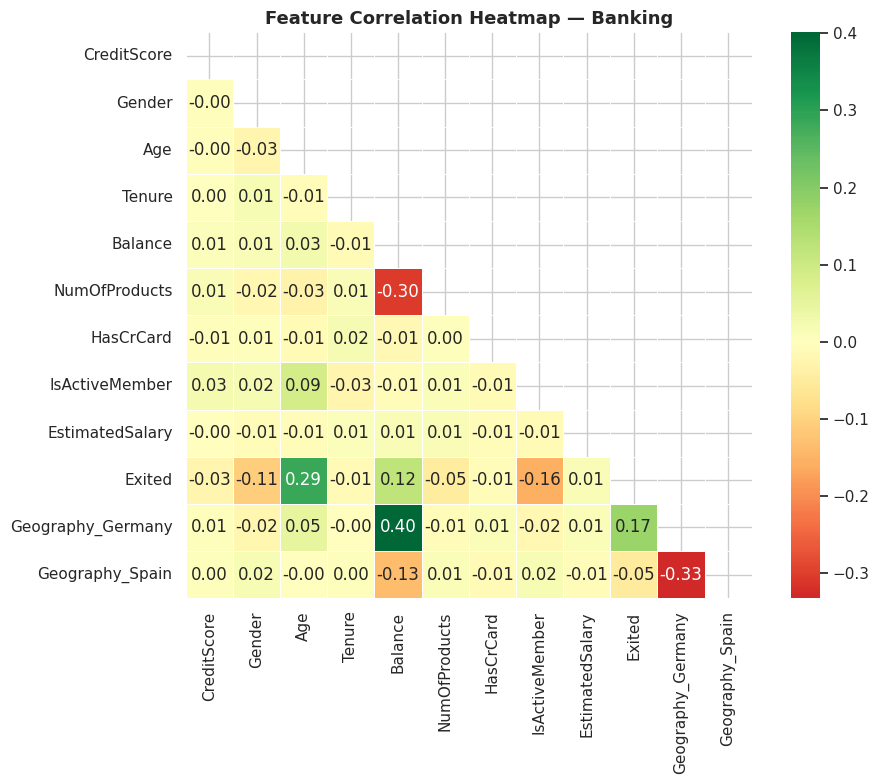

 Heatmap saved!


In [ ]:

plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap — Banking', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('banking_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Heatmap saved!")

In [ ]:
X = df.drop(columns=['Exited'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train : {X_train.shape}")
print(f" X_test  : {X_test.shape}")
print(f" y_train churn rate: {y_train.mean()*100:.2f}%")
print(f" y_test  churn rate: {y_test.mean()*100:.2f}%")

X_train : (8000, 11)
 X_test  : (2000, 11)
 y_train churn rate: 20.38%
 y_test  churn rate: 20.35%


In [ ]:
df.to_csv('banking_preprocessed.csv', index=False)
X_train.to_csv('X_train_banking.csv', index=False)
X_test.to_csv('X_test_banking.csv', index=False)
y_train.to_csv('y_train_banking.csv', index=False)
y_test.to_csv('y_test_banking.csv', index=False)


## done with the preprocessing

- German customers churn most (~32%)
-  Older customers (40–60) churn more
-  Inactive members churn almost 2x more
-  Customers with 3–4 products churn heavily
- Balance=0 customers show high churn risk

summary

In [ ]:
X_train, X_test, y_train, y_test

(      CreditScore  Gender       Age    Tenure   Balance  NumOfProducts  \
 2151     1.060247       1  1.723821  0.687130 -1.225848      -0.911583   
 8392     0.915392       1 -0.660018 -0.695982  0.410973      -0.911583   
 5006     1.080940       0 -0.183251 -1.733315  0.599083       0.807737   
 4117    -0.926334       1 -0.183251 -0.004426 -1.225848       0.807737   
 7182     0.429093       1  0.960993  0.341352  0.545796       0.807737   
 ...           ...     ...       ...       ...       ...            ...   
 4555     0.387706       0 -0.373958  0.341352 -1.225848      -0.911583   
 4644     0.636029       1  3.344832 -0.004426 -1.225848       0.807737   
 8942     0.170424       0 -0.183251  1.378686 -0.075311       0.807737   
 2935     0.377359       1 -0.373958  1.032908  0.392704       0.807737   
 6206     1.567239       1  1.151700  0.687130 -1.225848      -0.911583   
 
       HasCrCard  IsActiveMember  EstimatedSalary  Geography_Germany  \
 2151          1          

In [ ]:
print(f" X_train : {X_train.shape}")
print(f" X_test  : {X_test.shape}")
print(f" Train churn rate: {y_train.mean()*100:.2f}%")
print(f" Test  churn rate: {y_test.mean()*100:.2f}%")

 X_train : (8000, 11)
 X_test  : (2000, 11)
 Train churn rate: 20.38%
 Test  churn rate: 20.35%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")



Before — Class 0: 6370  | Class 1: 1630
After  — Class 0: 6370  | Class 1: 6370
Classes balanced!


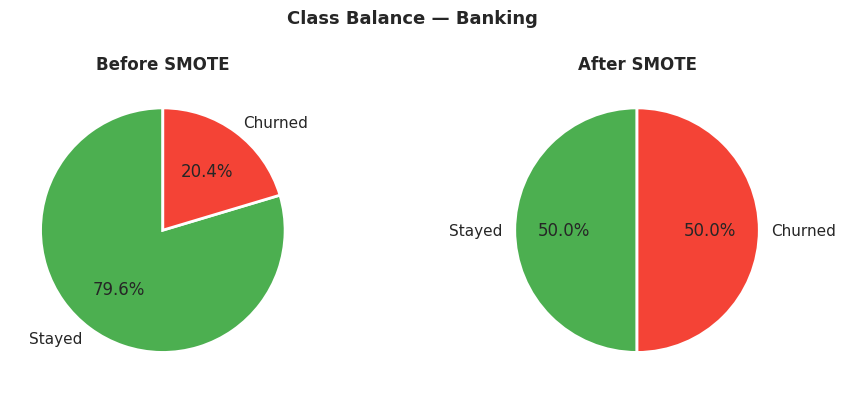

In [ ]:
print(f"Before — Class 0: {(y_train==0).sum()}  | Class 1: {(y_train==1).sum()}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After  — Class 0: {(y_train_sm==0).sum()}  | Class 1: {(y_train_sm==1).sum()}")
print("Classes balanced!")

# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y, title in zip(axes,
                         [y_train, y_train_sm],
                         ['Before SMOTE', 'After SMOTE']):
    ax.pie([(y==0).sum(), (y==1).sum()],
           labels=['Stayed', 'Churned'],
           autopct='%1.1f%%',
           colors=['#4CAF50', '#F44336'],
           startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax.set_title(title, fontweight='bold')

plt.suptitle('Class Balance — Banking', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('banking_smote.png', dpi=150, bbox_inches='tight')
plt.show()

helper function

In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train, evaluate and return results for a model."""

    print(f"\n{'─'*50}")
    print(f"  MODEL: {name}")
    print(f"{'─'*50}")

    model.fit(X_tr, y_tr)
    y_pred      = model.predict(X_te)
    y_pred_prob = model.predict_proba(X_te)[:, 1]

    acc     = accuracy_score(y_te, y_pred)
    roc_auc = roc_auc_score(y_te, y_pred_prob)
    cv      = cross_val_score(model, X_tr, y_tr,
                               cv=StratifiedKFold(5), scoring='roc_auc')

    print(f"  Accuracy      : {acc*100:.2f}%")
    print(f"  ROC-AUC       : {roc_auc:.4f}")
    print(f"  CV ROC-AUC    : {cv.mean():.4f} ± {cv.std():.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred, target_names=['Stayed', 'Churned']))

    return {
        'name'    : name,
        'model'   : model,
        'y_pred'  : y_pred,
        'y_prob'  : y_pred_prob,
        'accuracy': acc,
        'roc_auc' : roc_auc,
        'cv_mean' : cv.mean(),
        'cv_std'  : cv.std()
    }


In [ ]:
#logistic regression
lr_result = evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    X_train_sm, y_train_sm, X_test, y_test
)


──────────────────────────────────────────────────
  MODEL: Logistic Regression
──────────────────────────────────────────────────
  Accuracy      : 72.45%
  ROC-AUC       : 0.7673
  CV ROC-AUC    : 0.8073 ± 0.0281

  Classification Report:
              precision    recall  f1-score   support

      Stayed       0.89      0.74      0.81      1593
     Churned       0.39      0.65      0.49       407

    accuracy                           0.72      2000
   macro avg       0.64      0.70      0.65      2000
weighted avg       0.79      0.72      0.75      2000



In [ ]:
#random forest
rf_result = evaluate_model(
    "Random Forest",
    RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    X_train_sm, y_train_sm, X_test, y_test
)



──────────────────────────────────────────────────
  MODEL: Random Forest
──────────────────────────────────────────────────
  Accuracy      : 82.30%
  ROC-AUC       : 0.8587
  CV ROC-AUC    : 0.9301 ± 0.0255

  Classification Report:
              precision    recall  f1-score   support

      Stayed       0.91      0.86      0.89      1593
     Churned       0.55      0.68      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.75      2000
weighted avg       0.84      0.82      0.83      2000



In [ ]:
#xgb_boost
xgb_result = evaluate_model(
    "XGBoost",
    XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    X_train_sm, y_train_sm, X_test, y_test
)


──────────────────────────────────────────────────
  MODEL: XGBoost
──────────────────────────────────────────────────
  Accuracy      : 85.15%
  ROC-AUC       : 0.8690
  CV ROC-AUC    : 0.9491 ± 0.0417

  Classification Report:
              precision    recall  f1-score   support

      Stayed       0.91      0.91      0.91      1593
     Churned       0.64      0.63      0.63       407

    accuracy                           0.85      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000




 Comparison Table:


,Model,Accuracy,ROC-AUC,CV ROC-AUC
0,Logistic Regression,72.45%,0.7673,0.8073 ± 0.0281
1,Random Forest,82.30%,0.8587,0.9301 ± 0.0255
2,XGBoost,85.15%,0.8690,0.9491 ± 0.0417


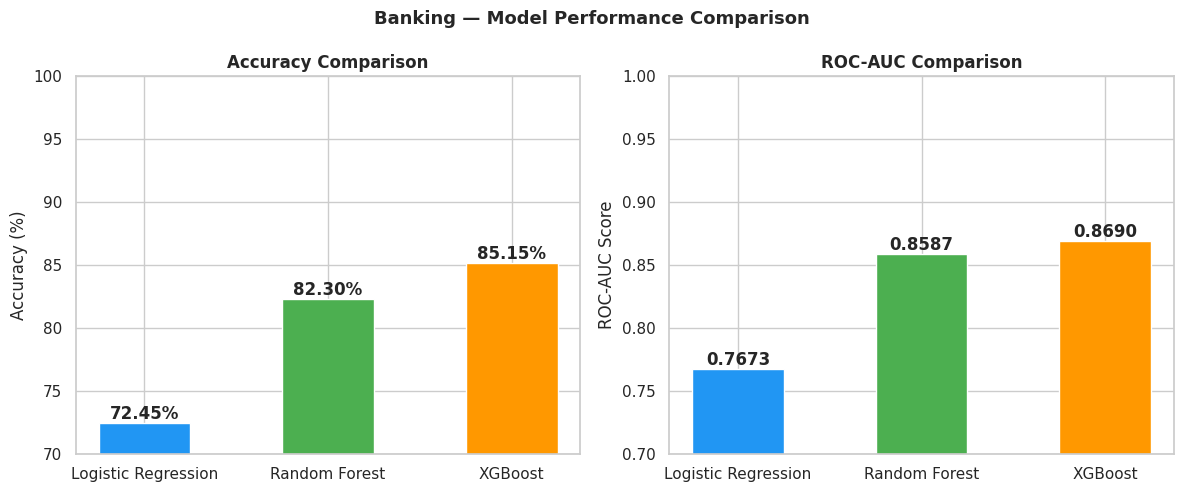

In [ ]:
results = [lr_result, rf_result, xgb_result]

comparison_df = pd.DataFrame([{
    'Model'     : r['name'],
    'Accuracy'  : f"{r['accuracy']*100:.2f}%",
    'ROC-AUC'   : f"{r['roc_auc']:.4f}",
    'CV ROC-AUC': f"{r['cv_mean']:.4f} ± {r['cv_std']:.4f}"
} for r in results])

print("\n Comparison Table:")
display(comparison_df)

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
names  = [r['name'] for r in results]
accs   = [r['accuracy']*100 for r in results]
aucs   = [r['roc_auc'] for r in results]
colors = ['#2196F3', '#4CAF50', '#FF9800']

axes[0].bar(names, accs, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(70, 100)
for i, v in enumerate(accs):
    axes[0].text(i, v+0.3, f'{v:.2f}%', ha='center', fontweight='bold')

axes[1].bar(names, aucs, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('ROC-AUC Comparison', fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0.7, 1.0)
for i, v in enumerate(aucs):
    axes[1].text(i, v+0.003, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Banking — Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('banking_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

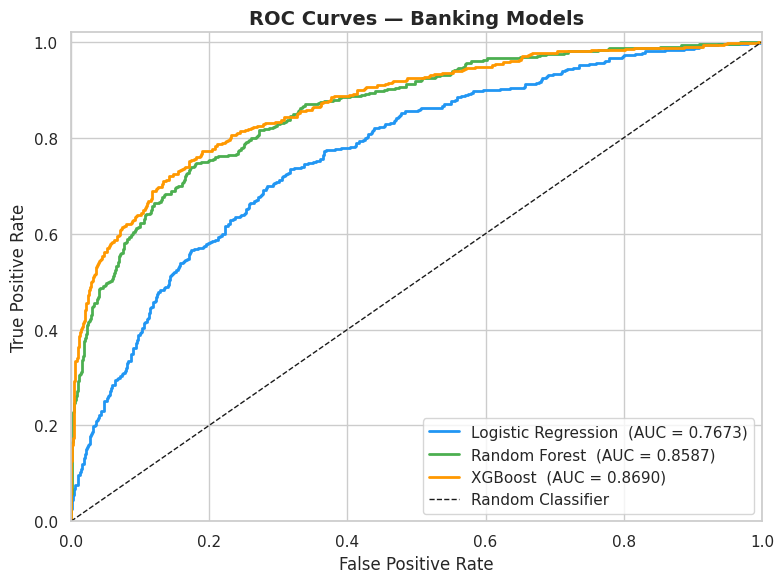

ROC curves saved!


In [ ]:
plt.figure(figsize=(8, 6))
colors_roc = ['#2196F3', '#4CAF50', '#FF9800']

for r, c in zip(results, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr, color=c, lw=2,
             label=f"{r['name']}  (AUC = {r['roc_auc']:.4f})")

plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Banking Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
#plt.savefig('banking_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curves saved!")


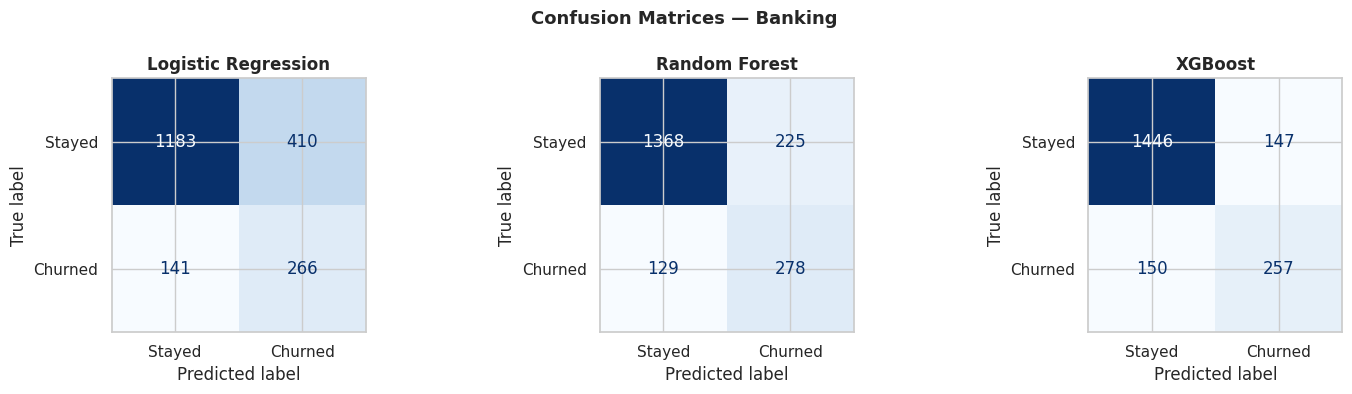

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, r in zip(axes, results):
    cm   = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(r['name'], fontweight='bold')

plt.suptitle('Confusion Matrices — Banking', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('banking_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


Best Model: XGBoost  (ROC-AUC: 0.8690)


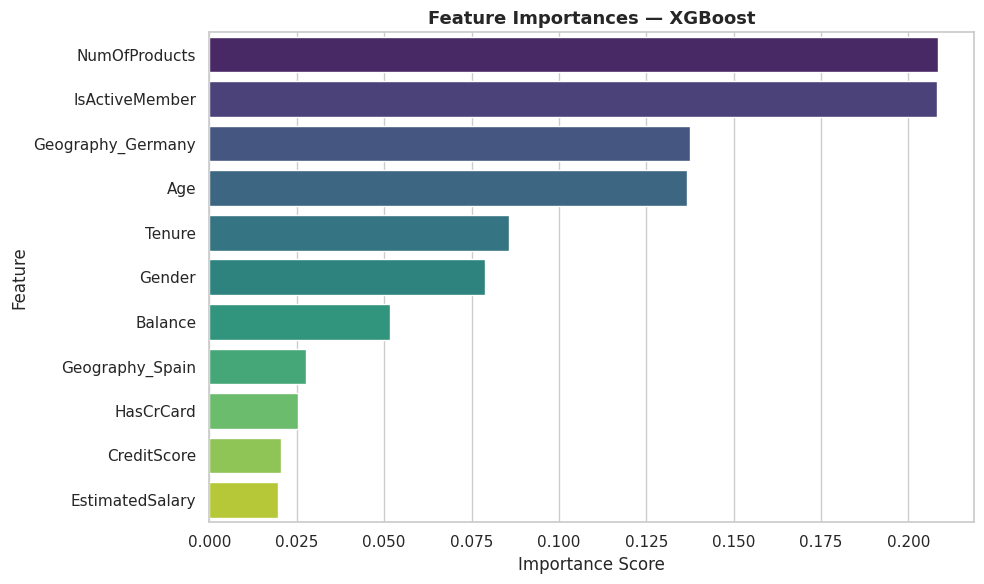


Top 10 Features Driving Churn:


,Feature,Importance
5,NumOfProducts,0.208346
7,IsActiveMember,0.208124
9,Geography_Germany,0.137635
2,Age,0.136594
3,Tenure,0.085860
1,Gender,0.078776
4,Balance,0.051607
10,Geography_Spain,0.027586
6,HasCrCard,0.025458
0,CreditScore,0.020520


In [ ]:
best_result = max(results, key=lambda x: x['roc_auc'])
best_model  = best_result['model']
print(f"Best Model: {best_result['name']}  (ROC-AUC: {best_result['roc_auc']:.4f})")

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])

feat_imp = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature',
            palette='viridis', edgecolor='white')
plt.title(f'Feature Importances — {best_result["name"]}',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
#plt.savefig('banking_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Features Driving Churn:")
display(feat_imp.head(10))



 Sample Predictions with Risk & Suggestions:


,Churn_Probability,Actual_Exited,Risk_Level,Suggestion
0,0.0215,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...
1,0.3204,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...
2,0.1039,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...
3,0.1449,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...
4,0.2029,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...
5,0.4688,0,Medium Risk 🟡,Showing early warning signs. Offer a personali...
6,0.0840,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...
7,0.3390,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...
8,0.6250,0,Medium Risk 🟡,Showing early warning signs. Offer a personali...
9,0.2001,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...



 Risk Distribution:
Risk_Level
Low Risk 🟢       1388
Medium Risk 🟡     345
High Risk 🔴       267
Name: count, dtype: int64


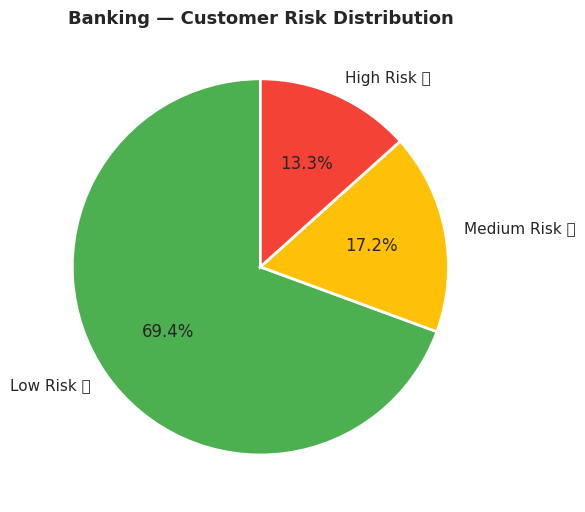

In [ ]:
def assign_risk(prob):
    if prob < 0.35:   return 'Low Risk 🟢'
    elif prob < 0.65: return 'Medium Risk 🟡'
    else:             return 'High Risk 🔴'

def get_suggestion(prob):
    if prob < 0.35:
        return "Customer is loyal. Maintain regular engagement & reward loyalty."
    elif prob < 0.65:
        return "Showing early warning signs. Offer a personalized product or check-in."
    else:
        return "Urgent! Assign a relationship manager, offer exclusive benefits immediately."

risk_df = pd.DataFrame({
    'Churn_Probability': best_result['y_prob'].round(4),
    'Actual_Exited'    : y_test.values,
    'Risk_Level'       : [assign_risk(p) for p in best_result['y_prob']],
    'Suggestion'       : [get_suggestion(p) for p in best_result['y_prob']]
})

print("\n Sample Predictions with Risk & Suggestions:")
display(risk_df.head(15))

print("\n Risk Distribution:")
print(risk_df['Risk_Level'].value_counts())

# Risk pie chart
total     = len(risk_df)
high_risk = (risk_df['Risk_Level'] == 'High Risk 🔴').sum()
med_risk  = (risk_df['Risk_Level'] == 'Medium Risk 🟡').sum()
low_risk  = (risk_df['Risk_Level'] == 'Low Risk 🟢').sum()

plt.figure(figsize=(6, 6))
plt.pie(
    [low_risk, med_risk, high_risk],
    labels=['Low Risk 🟢', 'Medium Risk 🟡', 'High Risk 🔴'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#FFC107', '#F44336'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Banking — Customer Risk Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('banking_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
joblib.dump(best_model, 'banking_churn_model.pkl')
joblib.dump(X_train.columns.tolist(), 'banking_feature_columns.pkl')

print(f" Saved: banking_churn_model.pkl")
print(f" Saved: banking_feature_columns.pkl")
print(f"   Model   : {type(best_model).__name__}")
print(f"   Features: {X_train.shape[1]}")

# Test reload
loaded = joblib.load('banking_churn_model.pkl')
test_p = loaded.predict_proba(X_test[:5])[:, 1]


 Saved: banking_churn_model.pkl
 Saved: banking_feature_columns.pkl
   Model   : XGBClassifier
   Features: 11


In [ ]:
# import shutil, os

# save_path = '/content/drive/MyDrive/churn_platform/banking/'
# os.makedirs(save_path, exist_ok=True)

# files_to_save = [
#     'banking_churn_model.pkl',
#     'banking_feature_columns.pkl',
#     'banking_smote.png',
#     'banking_model_comparison.png',
#     'banking_roc_curves.png',
#     'banking_confusion_matrices.png',
#     'banking_feature_importance.png',
#     'banking_risk_distribution.png',
# ]

In [ ]:
# for f in files_to_save:
#     try:
#         shutil.copy(f, save_path + f)
#         print(f" Saved to Drive: {f}")
#     except Exception as e:
#         print(f"  Skipped: {f} — {e}")

In [ ]:
print(f"""
   {total} Bank Customers Analyzed
  ─────────────────────────────────────────────
  High Risk   : {high_risk} customers ({high_risk/total*100:.1f}%)
                   → Likely to close account soon. Act now!

   Medium Risk : {med_risk} customers ({med_risk/total*100:.1f}%)
                   → Showing warning signs. Engage proactively.

   Low Risk    : {low_risk} customers ({low_risk/total*100:.1f}%)
                   → Loyal customers. Maintain relationship.

   Best Model  : {best_result['name']}
   Accuracy    : {best_result['accuracy']*100:.2f}%
   ROC-AUC     : {best_result['roc_auc']:.4f}
  ────────────────────────────────────────────
   Top Churn Drivers:
     • Age (older customers churn more)
     • Number of products (3-4 products = high risk)
     • Active membership (inactive = danger)
     • Geography (Germany highest churn ~32%)
     • Account balance patterns
""")


   2000 Bank Customers Analyzed
  ─────────────────────────────────────────────
  High Risk   : 267 customers (13.4%)
                   → Likely to close account soon. Act now!
 
   Medium Risk : 345 customers (17.2%)
                   → Showing warning signs. Engage proactively.
 
   Low Risk    : 1388 customers (69.4%)
                   → Loyal customers. Maintain relationship.
 
   Best Model  : XGBoost
   Accuracy    : 85.15%
   ROC-AUC     : 0.8690
  ────────────────────────────────────────────
   Top Churn Drivers:
     • Age (older customers churn more)
     • Number of products (3-4 products = high risk)
     • Active membership (inactive = danger)
     • Geography (Germany highest churn ~32%)
     • Account balance patterns



In [ ]:
# hypertuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

params = {
    'n_estimators'    : [100, 200, 300, 400],
    'max_depth'       : [3, 4, 5, 6, 7],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1],
    'subsample'       : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_distributions=params,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_sm, y_train_sm)

print(f"Best Params : {random_search.best_params_}")
print(f"Best ROC-AUC: {random_search.best_score_:.4f}")

#  Evaluate tuned model
best_tuned_model = random_search.best_estimator_
y_pred  = best_tuned_model.predict(X_test)
y_prob  = best_tuned_model.predict_proba(X_test)[:, 1]

print(f"\nTuned Model Results:")
print(f"   Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"   ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

# Save tuned model
import joblib
joblib.dump(best_tuned_model, 'banking_churn_model_tuned.pkl')
print(f"\nTuned model saved: banking_churn_model_tuned.pkl")

# Save to Drive
import shutil
shutil.copy(
    'banking_churn_model_tuned.pkl',
    '/content/drive/MyDrive/churn_platform/banking/banking_churn_model_tuned.pkl'
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params : {'subsample': 0.6, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best ROC-AUC: 0.9651

Tuned Model Results:
   Accuracy : 84.80%
   ROC-AUC  : 0.8332

Tuned model saved: banking_churn_model_tuned.pkl


'/content/drive/MyDrive/churn_platform/banking/banking_churn_model_tuned.pkl'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

save_path = '/content/drive/MyDrive/churn_platform/banking/'
os.makedirs(save_path, exist_ok=True)

files_to_save = [
    'Churn_Modelling.csv',
    'X_test_banking.csv',
    'X_train_banking.csv',
    'banking_churn_model.pkl',
    'banking_churn_model_tuned.pkl',
    'banking_feature_columns.pkl',
    'banking_preprocessed.csv',
    'banking_risk_distribution.png',
    'y_test_banking.csv',
    'y_train_banking.csv',
]

print("Saving all banking files to Drive...\n")
for f in files_to_save:
    try:
        shutil.copy(f'/content/{f}', save_path + f)
        print(f"  ✅ {f}")
    except:
        print(f"  ⚠️  Skipped: {f}")

print(f"\n🎉 Done! Check Drive → churn_platform/banking/")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving all banking files to Drive...

  ✅ Churn_Modelling.csv
  ✅ X_test_banking.csv
  ✅ X_train_banking.csv
  ✅ banking_churn_model.pkl
  ✅ banking_churn_model_tuned.pkl
  ✅ banking_feature_columns.pkl
  ✅ banking_preprocessed.csv
  ✅ banking_risk_distribution.png
  ✅ y_test_banking.csv
  ✅ y_train_banking.csv

🎉 Done! Check Drive → churn_platform/banking/



APPROACH 1 — STACKING CLASSIFIER

🏆 Stacking Results:
   Accuracy : 84.25%
   ROC-AUC  : 0.8635

              precision    recall  f1-score   support

      Stayed       0.91      0.90      0.90      1593
     Churned       0.61      0.63      0.62       407

    accuracy                           0.84      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.85      0.84      0.84      2000


APPROACH 2 — THRESHOLD TUNING
 Best Threshold : 0.83
 Best Accuracy  : 87.25%

 Threshold Tuned Results:
   Accuracy : 87.25%
   ROC-AUC  : 0.8635

              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
     Churned       0.83      0.47      0.60       407

    accuracy                           0.87      2000
   macro avg       0.85      0.72      0.76      2000
weighted avg       0.87      0.87      0.86      2000



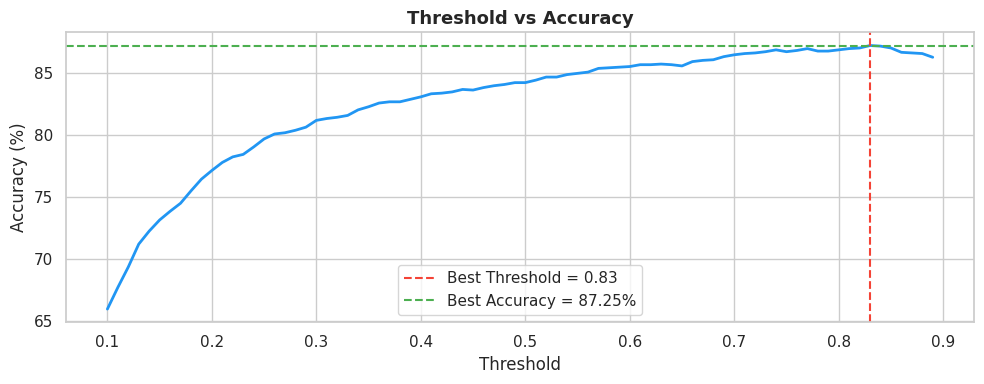

 Threshold chart saved!

APPROACH 3 — POWER XGBOOST
[0]	validation_0-logloss:0.68164
[100]	validation_0-logloss:0.41025
[200]	validation_0-logloss:0.37407
[300]	validation_0-logloss:0.35722
[400]	validation_0-logloss:0.35079
[499]	validation_0-logloss:0.35029

🏆 Power XGBoost Results:
   Accuracy : 85.70%
   ROC-AUC  : 0.8570

              precision    recall  f1-score   support

      Stayed       0.90      0.92      0.91      1593
     Churned       0.67      0.59      0.63       407

    accuracy                           0.86      2000
   macro avg       0.78      0.76      0.77      2000
weighted avg       0.85      0.86      0.85      2000


CELL 5 — FINAL COMPARISON

▶ All Approaches Comparison:


,Approach,Accuracy,ROC-AUC
0,Stacking Classifier,84.25%,0.8635
1,Threshold Tuning (t=0.83),87.25%,0.8635
2,Power XGBoost,85.70%,0.8570


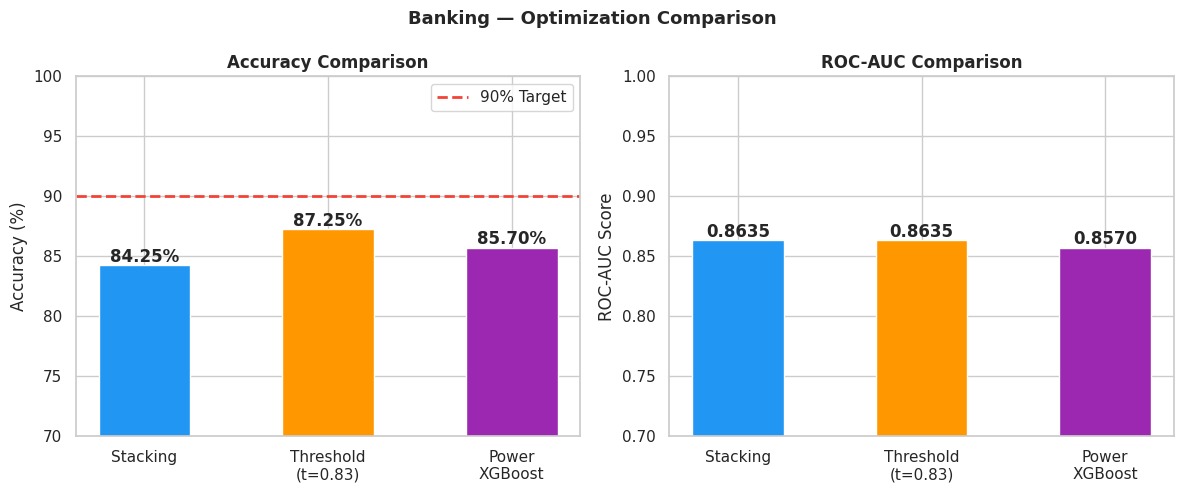


CELL 6 — SAVE BEST MODEL
Best Model  : Power XGBoost
   Accuracy    : 85.70%
   Best Thresh : 0.83

 Saved locally!
 Saved to Drive: banking_churn_best_model.pkl
 Saved to Drive: banking_best_threshold.pkl
 Saved to Drive: banking_feature_columns.pkl
 Saved to Drive: banking_threshold_tuning.png
 Saved to Drive: banking_optimization_comparison.png

CELL 7 — FINAL RISK SCORING & SUGGESTIONS

▶ Sample Predictions:


,Churn_Probability,Predicted,Actual,Risk_Level,Suggestion
0,0.0159,0,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...
1,0.3259,0,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...
2,0.0649,0,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...
3,0.1153,0,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...
4,0.1444,0,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...
5,0.4043,0,0,Medium Risk 🟡,Showing early warning signs. Offer a personali...
6,0.0525,0,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...
7,0.2509,0,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...
8,0.5725,0,0,Medium Risk 🟡,Showing early warning signs. Offer a personali...
9,0.1611,0,0,Low Risk 🟢,Customer is loyal. Maintain regular engagement...


✅ Predictions saved to Drive!

  📊 2000 Bank Customers Analyzed
  ─────────────────────────────────────
  🔴 High Risk   : 247 (12.3%) → Act immediately!
  🟡 Medium Risk : 289 (14.4%) → Monitor closely
  🟢 Low Risk    : 1464 (73.2%) → Stable customers

  🏆 Best Model  : Power XGBoost
  📈 Accuracy    : 85.70%
  🎯 Threshold   : 0.83

🎉 BANKING OPTIMIZATION COMPLETE!


In [ ]:


from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, StackingClassifier
from sklearn.metrics         import (accuracy_score, roc_auc_score,
                                     classification_report, confusion_matrix,
                                     ConfusionMatrixDisplay, roc_curve)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.over_sampling  import SMOTE
from xgboost                 import XGBClassifier

sns.set_theme(style="whitegrid")



# ────────────────────────────────────────────
# CELL 2 — APPROACH 1: STACKING CLASSIFIER
# ────────────────────────────────────────────
print("\n" + "="*55)
print("APPROACH 1 — STACKING CLASSIFIER")
print("="*55)

estimators = [
    ('xgb', XGBClassifier(
        subsample        = 0.6,
        n_estimators     = 300,
        min_child_weight = 3,
        max_depth        = 5,
        learning_rate    = 0.05,
        colsample_bytree = 0.8,
        eval_metric      = 'logloss',
        random_state     = 42
    )),
    ('rf', RandomForestClassifier(
        n_estimators = 300,
        max_depth    = 10,
        class_weight = 'balanced',
        random_state = 42,
        n_jobs       = -1
    )),
]

stacking_model = StackingClassifier(
    estimators     = estimators,
    final_estimator= LogisticRegression(max_iter=1000),
    cv             = 5,
    n_jobs         = -1
)

stacking_model.fit(X_train_sm, y_train_sm)

stacking_pred = stacking_model.predict(X_test)
stacking_prob = stacking_model.predict_proba(X_test)[:, 1]
stacking_acc  = accuracy_score(y_test, stacking_pred)
stacking_auc  = roc_auc_score(y_test, stacking_prob)

print(f"\n🏆 Stacking Results:")
print(f"   Accuracy : {stacking_acc*100:.2f}%")
print(f"   ROC-AUC  : {stacking_auc:.4f}")
print(f"\n{classification_report(y_test, stacking_pred, target_names=['Stayed','Churned'])}")


# ────────────────────────────────────────────
# CELL 3 — APPROACH 2: THRESHOLD TUNING
# ────────────────────────────────────────────
print("\n" + "="*55)
print("APPROACH 2 — THRESHOLD TUNING")
print("="*55)

# Use stacking probabilities for threshold tuning
thresholds = np.arange(0.1, 0.9, 0.01)
best_thresh = 0.5
best_acc    = 0

for t in thresholds:
    y_pred_t = (stacking_prob >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    if acc > best_acc:
        best_acc    = acc
        best_thresh = t

print(f" Best Threshold : {best_thresh:.2f}")
print(f" Best Accuracy  : {best_acc*100:.2f}%")

y_pred_tuned = (stacking_prob >= best_thresh).astype(int)
tuned_auc    = roc_auc_score(y_test, stacking_prob)

print(f"\n Threshold Tuned Results:")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_tuned)*100:.2f}%")
print(f"   ROC-AUC  : {tuned_auc:.4f}")
print(f"\n{classification_report(y_test, y_pred_tuned, target_names=['Stayed','Churned'])}")

# Plot threshold vs accuracy
plt.figure(figsize=(10, 4))
accs = [accuracy_score(y_test, (stacking_prob >= t).astype(int)) for t in thresholds]
plt.plot(thresholds, [a*100 for a in accs], color='#2196F3', lw=2)
plt.axvline(x=best_thresh, color='#F44336', linestyle='--',
            label=f'Best Threshold = {best_thresh:.2f}')
plt.axhline(y=best_acc*100, color='#4CAF50', linestyle='--',
            label=f'Best Accuracy = {best_acc*100:.2f}%')
plt.xlabel('Threshold')
plt.ylabel('Accuracy (%)')
plt.title('Threshold vs Accuracy', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('banking_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Threshold chart saved!")


# ────────────────────────────────────────────
# CELL 4 — APPROACH 3: POWER XGBOOST
# ────────────────────────────────────────────
print("\n" + "="*55)
print("APPROACH 3 — POWER XGBOOST")
print("="*55)

power_model = XGBClassifier(
    n_estimators     = 500,
    max_depth        = 6,
    learning_rate    = 0.03,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 1,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.5,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1
)

power_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=100
)

power_pred = power_model.predict(X_test)
power_prob = power_model.predict_proba(X_test)[:, 1]
power_acc  = accuracy_score(y_test, power_pred)
power_auc  = roc_auc_score(y_test, power_prob)

print(f"\n Power XGBoost Results:")
print(f"   Accuracy : {power_acc*100:.2f}%")
print(f"   ROC-AUC  : {power_auc:.4f}")
print(f"\n{classification_report(y_test, power_pred, target_names=['Stayed','Churned'])}")


# ────────────────────────────────────────────
# CELL 5 — COMPARE ALL APPROACHES
# ────────────────────────────────────────────
print("\n" + "="*55)
print("CELL 5 — FINAL COMPARISON")
print("="*55)

comparison = pd.DataFrame([
    {
        'Approach' : 'Stacking Classifier',
        'Accuracy' : f"{stacking_acc*100:.2f}%",
        'ROC-AUC'  : f"{stacking_auc:.4f}"
    },
    {
        'Approach' : f'Threshold Tuning (t={best_thresh:.2f})',
        'Accuracy' : f"{best_acc*100:.2f}%",
        'ROC-AUC'  : f"{tuned_auc:.4f}"
    },
    {
        'Approach' : 'Power XGBoost',
        'Accuracy' : f"{power_acc*100:.2f}%",
        'ROC-AUC'  : f"{power_auc:.4f}"
    },
])

print("\n▶ All Approaches Comparison:")
display(comparison)

# Bar chart
approaches = ['Stacking', f'Threshold\n(t={best_thresh:.2f})', 'Power\nXGBoost']
accs_all   = [stacking_acc*100, best_acc*100, power_acc*100]
aucs_all   = [stacking_auc, tuned_auc, power_auc]
colors     = ['#2196F3', '#FF9800', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(approaches, accs_all, color=colors, edgecolor='white', width=0.5)
axes[0].axhline(y=90, color='#F44336', linestyle='--', lw=2, label='90% Target')
axes[0].set_title('Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(70, 100)
axes[0].legend()
for i, v in enumerate(accs_all):
    axes[0].text(i, v+0.3, f'{v:.2f}%', ha='center', fontweight='bold')

axes[1].bar(approaches, aucs_all, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('ROC-AUC Comparison', fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0.7, 1.0)
for i, v in enumerate(aucs_all):
    axes[1].text(i, v+0.003, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Banking — Optimization Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('banking_optimization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ────────────────────────────────────────────
# CELL 6 — PICK & SAVE BEST MODEL
# ────────────────────────────────────────────
print("\n" + "="*55)
print("CELL 6 — SAVE BEST MODEL")
print("="*55)

# Pick best by accuracy
all_results = {
    'Stacking'    : (stacking_model, stacking_acc),
    'Power XGBoost': (power_model,   power_acc),
}

best_name  = max(all_results, key=lambda x: all_results[x][1])
best_model = all_results[best_name][0]
best_acc_f = all_results[best_name][1]

print(f"Best Model  : {best_name}")
print(f"   Accuracy    : {best_acc_f*100:.2f}%")
print(f"   Best Thresh : {best_thresh:.2f}")

# Save model + threshold
joblib.dump(best_model,  'banking_churn_best_model.pkl')
joblib.dump(best_thresh, 'banking_best_threshold.pkl')
joblib.dump(X_train.columns.tolist(), 'banking_feature_columns.pkl')

print("\n Saved locally!")

# Save to Drive
save_path = '/content/drive/MyDrive/churn_platform/banking/'
os.makedirs(save_path, exist_ok=True)

files_to_save = [
    'banking_churn_best_model.pkl',
    'banking_best_threshold.pkl',
    'banking_feature_columns.pkl',
    'banking_threshold_tuning.png',
    'banking_optimization_comparison.png',
]

for f in files_to_save:
    try:
        shutil.copy(f, save_path + f)
        print(f" Saved to Drive: {f}")
    except Exception as e:
        print(f"⚠️  Skipped: {f} — {e}")


# ────────────────────────────────────────────
# CELL 7 — FINAL RISK SCORING
# ────────────────────────────────────────────
print("\n" + "="*55)
print("CELL 7 — FINAL RISK SCORING & SUGGESTIONS")
print("="*55)

def assign_risk(prob):
    if prob < 0.35:   return 'Low Risk 🟢'
    elif prob < 0.65: return 'Medium Risk 🟡'
    else:             return 'High Risk 🔴'

def get_suggestion(prob):
    if prob < 0.35:
        return "Customer is loyal. Maintain regular engagement & reward loyalty."
    elif prob < 0.65:
        return "Showing early warning signs. Offer a personalized product or check-in."
    else:
        return "Urgent! Assign a relationship manager, offer exclusive benefits immediately."

# Use best model probabilities
final_prob = best_model.predict_proba(X_test)[:, 1]
final_pred = (final_prob >= best_thresh).astype(int)

risk_df = pd.DataFrame({
    'Churn_Probability': final_prob.round(4),
    'Predicted'        : final_pred,
    'Actual'           : y_test.values,
    'Risk_Level'       : [assign_risk(p) for p in final_prob],
    'Suggestion'       : [get_suggestion(p) for p in final_prob]
})

print("\nSample Predictions:")
display(risk_df.head(15))

# Save predictions
risk_df.to_csv('banking_final_predictions.csv', index=False)
shutil.copy('banking_final_predictions.csv', save_path + 'banking_final_predictions.csv')
print(" Predictions saved to Drive!")

# Summary
total     = len(risk_df)
high_risk = (risk_df['Risk_Level'] == 'High Risk 🔴').sum()
med_risk  = (risk_df['Risk_Level'] == 'Medium Risk 🟡').sum()
low_risk  = (risk_df['Risk_Level'] == 'Low Risk 🟢').sum()

print(f"""
  📊 {total} Bank Customers Analyzed
  ─────────────────────────────────────
  🔴 High Risk   : {high_risk} ({high_risk/total*100:.1f}%) → Act immediately!
  🟡 Medium Risk : {med_risk} ({med_risk/total*100:.1f}%) → Monitor closely
  🟢 Low Risk    : {low_risk} ({low_risk/total*100:.1f}%) → Stable customers

  🏆 Best Model  : {best_name}
  📈 Accuracy    : {best_acc_f*100:.2f}%
  🎯 Threshold   : {best_thresh:.2f}
""")

print("="*55)
print("🎉 BANKING OPTIMIZATION COMPLETE!")